# Numerical Solution to Pohlhausen

Recall our full steady Navier-Stokes and thermal energy equations are:

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

$$u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

$$u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right)$$

For a boundary layer developing over a flat plate of length $L$, the characteristic length in the streamwise direction is $L$, and the boundary layer thickness is $\delta$. The core assumption is that the boundary layer is very thin: $\delta \ll L$. By assigning orders of magnitude, i.e., $u \sim U_\infty$, $x \sim L$, and $y \sim \delta$, we enforce continuity to find that the transverse velocity scales as $v \sim U_\infty(\delta/L)$. Because $\delta \ll L$, it follows that $v \ll u$. Applying these scales to the momentum equation reveals that the streamwise diffusion term $\nu \frac{\partial^2 u}{\partial x^2}$ scales as $\nu \frac{U_\infty}{L^2}$, while transverse diffusion $\nu \frac{\partial^2 u}{\partial y^2}$ scales as $\nu \frac{U_\infty}{\delta^2}$. The ratio of these terms is $(\delta/L)^2 \ll 1$, allowing us to safely neglect streamwise diffusion. Furthermore, outside the boundary layer, the freestream velocity $U_\infty$ is constant. Bernoulli's equation for the inviscid outer flow dictates that $-\frac{1}{\rho}\frac{\partial p}{\partial x} = U_\infty \frac{\partial U_\infty}{\partial x} = 0$. Transverse momentum analysis similarly shows that $\frac{\partial p}{\partial y} \approx 0$, meaning the constant pressure of the freestream is imposed throughout the boundary layer depth. Applying the scale analysis drops the pressure gradient and streamwise diffusion terms, yielding the parabolic boundary layer equations:

$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

$$u \frac{\partial u}{\partial x} + v \frac{\partial u}{\partial y} = \nu \frac{\partial^2 u}{\partial y^2}$$

$$u \frac{\partial T}{\partial x} + v \frac{\partial T}{\partial y} = \alpha \frac{\partial^2 T}{\partial y^2}$$

Because the equations are now strictly parabolic in the $x$-direction, we can march downstream from $x=0$ to $x=L$. Using a fully implicit formulation ensures numerical stability regardless of the step size $\Delta x$. Let index $i$ represent the known upstream station and $i+1$ the unknown downstream station. Let index $j$ represent the transverse nodes.

The streamwise derivative can be written using a backward Euler method:
$$\frac{\partial u}{\partial x} \approx \frac{u_{i+1,j} - u_{i,j}}{\Delta x}$$

The transverse derivative can be written using the central difference method:
$$\frac{\partial^2 u}{\partial y^2} \approx \frac{u_{i+1,j-1} - 2u_{i+1,j} + u_{i+1,j+1}}{\Delta y^2}$$

Transverse advection can be written as:
$$v \frac{\partial u}{\partial y} \approx v_{i,j} \frac{u_{i+1,j+1} - u_{i+1,j-1}}{2\Delta y}$$

We assume that the non-linear advection coefficient $u$ is lagged to the known value $i$. Substituting these into the momentum equation:

$$u_{i,j} \left( \frac{u_{i+1,j} - u_{i,j}}{\Delta x} \right) + v_{i,j} \left( \frac{u_{i+1,j+1} - u_{i+1,j-1}}{2\Delta y} \right) = \nu \left( \frac{u_{i+1,j-1} - 2u_{i+1,j} + u_{i+1,j+1}}{\Delta y^2} \right)$$

Rearranging to isolate the unknown variables at $i+1$ on the left side and moving known quantities to the right side produces a tridiagonal matrix formulation:

$$-\left( \frac{\nu}{\Delta y^2} + \frac{v_{i,j}}{2\Delta y} \right) u_{i+1,j-1} + \left( \frac{u_{i,j}}{\Delta x} + \frac{2\nu}{\Delta y^2} \right) u_{i+1,j} - \left( \frac{\nu}{\Delta y^2} - \frac{v_{i,j}}{2\Delta y} \right) u_{i+1,j+1} = \frac{u_{i,j}^2}{\Delta x}$$

The energy equation is discretized identically, swapping $\nu$ for $\alpha$, and solving for unknown temperatures $T_{i+1}$.

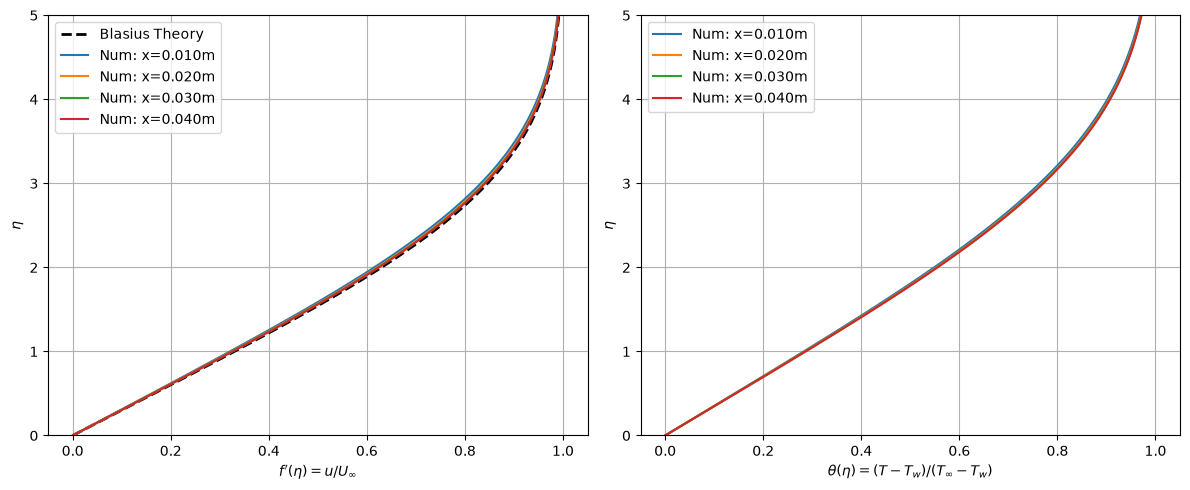

In [24]:
# code cell 
'''
This Python script translates the marching scheme and utilizes `scipy.linalg.solve_banded` to solve the tridiagonal system 
in true $\mathcal{O}(N)$ time. Furthermore, it explicitly calculates the theoretical Blasius ODE solution 
via `scipy.integrate.solve_bvp` so one can directly compare their numerical collapse against the exact self-similar curve.
'''

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.integrate import solve_bvp

# -------------------------------------
# Inputs and Mesh Generation
# -------------------------------------
L = 0.05
H = 0.01
U_inf = 1.0
T_inf = 300.0
T_wall = 350.0

nu = 1.5e-5
Pr = 0.6818
alpha = nu / Pr

nx = 1000
ny = 1000
dx = L / nx
dy = H / ny

y = np.linspace(0, H, ny)
x = np.linspace(0, L, nx)

# Initialization
u = np.ones((ny, nx)) * U_inf
v = np.zeros((ny, nx))
T = np.ones((ny, nx)) * T_inf

# Boundary Conditions
u[0, :] = 0.0       # No-slip wall
u[-1, :] = U_inf    # Freestream
T[0, :] = T_wall
T[-1, :] = T_inf

# -------------------------------------
# Implicit Marching Solver
# -------------------------------------
for i in range(nx - 1):
    u_old = u[:, i]
    v_old = v[:, i]
    
    # --- Solve Momentum ---
    # Coefficients for interior nodes
    c_diff = nu / dy**2
    c_adv_v = v_old[1:-1] / (2 * dy)
    
    lower = -c_diff - c_adv_v
    main  = (u_old[1:-1] / dx) + 2 * c_diff
    upper = -c_diff + c_adv_v
    rhs   = (u_old[1:-1]**2) / dx
    
    # Pack banded matrix (3 diagonals)
    ab = np.zeros((3, ny))
    ab[0, 2:]   = upper       # Upper diagonal
    ab[0, 1]    = 0.0         # Top BC upper
    ab[1, 1:-1] = main        # Main diagonal
    ab[1, 0]    = 1.0         # Bottom BC main
    ab[1, -1]   = 1.0         # Top BC main
    ab[2, :-2]  = lower       # Lower diagonal
    ab[2, -2]   = 0.0         # Bottom BC lower
    
    B = np.zeros(ny)
    B[1:-1] = rhs
    B[0] = 0.0                # u(0) = 0
    B[-1] = U_inf             # u(H) = U_inf
    
    # Solve banded system
    u[:, i+1] = solve_banded((1, 1), ab, B)
    
    # --- Solve Continuity ---
    # dv/dy = -du/dx (Trapezoidal integration / finite difference)
    for j in range(1, ny):
        v[j, i+1] = v[j-1, i+1] - (dy/dx) * (u[j, i+1] - u[j, i])
        
    # --- Solve Energy ---
    c_diff_t = alpha / dy**2
    c_adv_vt = v_old[1:-1] / (2 * dy)
    
    lower_t = -c_diff_t - c_adv_vt
    main_t  = (u_old[1:-1] / dx) + 2 * c_diff_t
    upper_t = -c_diff_t + c_adv_vt
    rhs_t   = (u_old[1:-1] * T[1:-1, i]) / dx
    
    ab_t = np.zeros((3, ny))
    ab_t[0, 2:]   = upper_t   # Upper diagonal
    ab_t[0, 1]    = 0.0
    ab_t[1, 1:-1] = main_t
    ab_t[1, 0]    = 1.0
    ab_t[1, -1]   = 1.0
    ab_t[2, :-2]  = lower_t   # Lower diagonal
    ab_t[2, -2]   = 0.0
    
    B_t = np.zeros(ny)
    B_t[1:-1] = rhs_t
    B_t[0] = T_wall
    B_t[-1] = T_inf
    
    T[:, i+1] = solve_banded((1, 1), ab_t, B_t)

# -------------------------------------
# 3. Blasius Solution
# -------------------------------------
def blasius_ode(eta, y_bvp):
    f, f_prime, f_double_prime = y_bvp
    return np.vstack((f_prime, f_double_prime, -0.5 * f * f_double_prime))

def blasius_bc(ya, yb):
    return np.array([ya[0], ya[1], yb[1] - 1.0])

eta_theory = np.linspace(0, 8, 500)
y_guess = np.zeros((3, eta_theory.size))
y_guess[1, :] = 1.0 
blasius_sol = solve_bvp(blasius_ode, blasius_bc, eta_theory, y_guess)
f_prime_theory = blasius_sol.sol(eta_theory)[1]

# -------------------------------------
# 4. Data Processing and Plotting
# -------------------------------------
X, Y = np.meshgrid(x[1:], y) 

# Similarity Variable (Eta)
Eta = Y * np.sqrt(U_inf / (nu * X))

# Non-dimensional variables
f_prime = u[:, 1:] / U_inf
Theta = (T[:, 1:] - T_wall) / (T_inf - T_wall)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

stations = [int(nx * pct) for pct in [0.2, 0.4, 0.6, 0.8]]

# Plot Velocity Comparison
ax1.plot(f_prime_theory, eta_theory, 'k--', linewidth=2, label='Blasius Theory')
for s in stations:
    ax1.plot(f_prime[:, s], Eta[:, s], '-', linewidth=1.5, label=f'Num: x={x[s]:.3f}m')

ax1.set_xlabel(r"$f'(\eta) = u/U_\infty$")
ax1.set_ylabel(r"$\eta$")
ax1.set_ylim([0, 5])
ax1.grid(True)
ax1.legend()
#ax1.set_title("Velocity Similarity Profile")

# Plot Temperature Similarity
for s in stations:
    ax2.plot(Theta[:, s], Eta[:, s], '-', linewidth=1.5, label=f'Num: x={x[s]:.3f}m')

ax2.set_xlabel(r"$\theta(\eta) = (T-T_w)/(T_\infty-T_w)$")
ax2.set_ylabel(r"$\eta$")
ax2.set_ylim([0, 5])
ax2.grid(True)
ax2.legend()
#ax2.set_title("Thermal Similarity Profile")

plt.tight_layout()
plt.savefig('../lectures/figures/eta_vs_f_vs_theta.pdf',dpi=300)
plt.show()



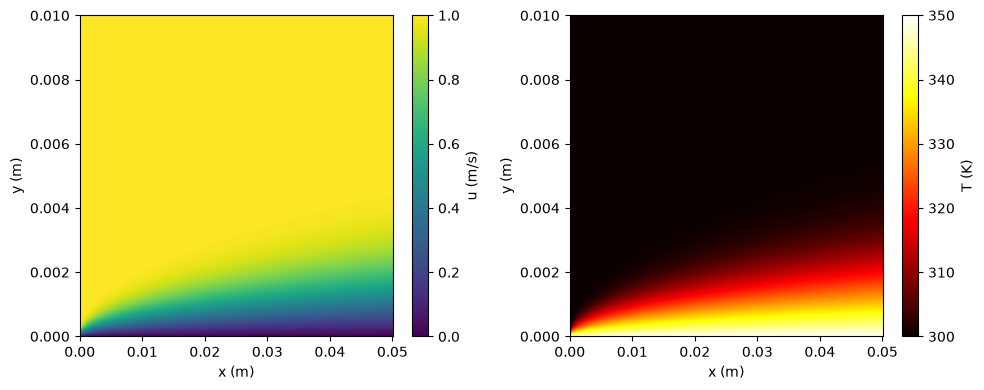

In [30]:
# Calculate the theoretical scale for vertical velocity v ~ U_inf * (delta / L)
delta_L = 5.0 * np.sqrt(nu * L / U_inf)
v_scale = U_inf * (delta_L / L)

# Create the full meshgrid for the contour plots
X_full, Y_full = np.meshgrid(x, y)

# Set up the figure with 3 subplots
# fig_contour, (ax1_contour, ax2_contour, ax3_contour) = plt.subplots(1, 3, figsize=(15, 4))
fig_contour, (ax1_contour, ax3_contour) = plt.subplots(1, 2, figsize=(10, 4))

# 1. Streamwise Velocity u (m/s)
c1 = ax1_contour.pcolormesh(X_full, Y_full, u, cmap='viridis', shading='auto')
cb1 = fig_contour.colorbar(c1, ax=ax1_contour)
cb1.set_label('u (m/s)') 
ax1_contour.set_xlabel('x (m)')
ax1_contour.set_ylabel('y (m)')

# 2. Transverse Velocity v (m/s)
# Apply vmax to clamp the maximum color scale to the theoretical order of magnitude
#c2 = ax2_contour.pcolormesh(X_full, Y_full, v, cmap='viridis', shading='auto', vmax=v_scale)
#cb2 = fig_contour.colorbar(c2, ax=ax2_contour)
#cb2.set_label('v (m/s)') 
#ax2_contour.set_xlabel('x (m)')
#ax2_contour.set_ylabel('y (m)')

# 3. Temperature (K)
c3 = ax3_contour.pcolormesh(X_full, Y_full, T, cmap='hot', shading='auto')
cb3 = fig_contour.colorbar(c3, ax=ax3_contour)
cb3.set_label('T (K)')   
ax3_contour.set_xlabel('x (m)')
ax3_contour.set_ylabel('y (m)')

plt.tight_layout()
#plt.savefig('../lectures/figures/pohlhausen_numerical_solution.pdf',dpi=300)
plt.savefig('../lectures/figures/pohlhausen_numerical_solution.png')
plt.show()